In [14]:
import importlib.util, sys, os

datasets_dir = "/beegfs/muduchuru/codes/physicsnemo/examples/weather/corrdiff/datasets"

# Create a package module object for 'datasets'
spec_pkg = importlib.util.spec_from_loader("datasets", loader=None)
pkg = importlib.util.module_from_spec(spec_pkg)
pkg.__path__ = [datasets_dir]
sys.modules["datasets"] = pkg

# Now load the submodule as 'datasets.mswx_dwd'
spec = importlib.util.spec_from_file_location("datasets.mswxdwd",
                                              os.path.join(datasets_dir, "mswxdwd.py"))
mod = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = mod
spec.loader.exec_module(mod)

print(mod.mswxdwd)  # class is available

<class 'datasets.mswxdwd.mswxdwd'>


In [ ]:
dataloader = mod.mswxdwd(
    data_path='/beegfs/muduchuru/data',
    input_channels = ['pr','tas'],
    output_channels = ['pr','tas'],
    static_channels = ['elevation', 'lsm', 'dwd_mask','pos_embed'],
    stats_dwd = '/beegfs/muduchuru/data/hyras_daily/hyras_stats.json',
    stats_mswx = '/beegfs/muduchuru/data/mswx/mswx_stats.json',
    center_latlon = [47.63, 10.13],
    )
data = dataloader[200]

/home/muduchuru/miniforge3/envs/diffusion/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


(array([[[ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         ...,
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ]],
 
        [[ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         ...,
         [16.5       , 16.5      

In [26]:
dataloader[200][1].shape

(7, 128, 128)

In [19]:
# Debug the coordinate calculation
import numpy as np
print("Data grid shape:", dataloader.lat.shape)
print("Data grid lat range:", dataloader.lat.min(), "to", dataloader.lat.max())
print("Data grid lon range:", dataloader.lon.min(), "to", dataloader.lon.max())
print("Requested center_latlon:", [49.3, 8.09])
print("Patch size:", dataloader.patch_size)

# Test the coordinate calculation using the corrected method
lat0, lon0 = 49.3, 8.09
ph, pw = 128, 128

# Use corrected method (2D coordinate search)
dist = np.sqrt((dataloader.lat - lat0)**2 + (dataloader.lon - lon0)**2)
iy, ix = np.unravel_index(np.argmin(dist), dataloader.lat.shape)
print(f"Closest point: iy={iy}, ix={ix}")
print(f"Closest lat value: {dataloader.lat[iy, ix]}")
print(f"Closest lon value: {dataloader.lon[iy, ix]}")

# Calculate patch bounds (for bottom-left coordinate)
top = int(iy - (ph - 1))
left = int(ix)
print(f"Before clipping - top: {top}, left: {left}")

# Apply clipping
top = np.clip(top, 0, dataloader.lat.shape[0] - ph)
left = np.clip(left, 0, dataloader.lat.shape[1] - pw)
print(f"After clipping - top: {top}, left: {left}")
print(f"Patch bounds: [{top}:{top+ph}, {left}:{left+pw}]")
print(f"Patch size will be: ({ph}, {left+pw-left})")  # Should be (128, 128)

Data grid shape: (867, 642)
Data grid lat range: 47.17506790161133 to 55.05985641479492
Data grid lon range: 5.476927280426025 to 15.488505363464355
Requested center_latlon: [49.3, 8.09]
Patch size: (128, 128)
Closest point: iy=227, ix=151
Closest lat value: 49.300357818603516
Closest lon value: 8.095903396606445
Before clipping - top: 100, left: 151
After clipping - top: 100, left: 151
Patch bounds: [100:228, 151:279]
Patch size will be: (128, 128)


In [20]:
dataloader.input_channels()

[ChannelMetadata(name='pr', level='', auxiliary=False),
 ChannelMetadata(name='tas', level='', auxiliary=False),
 ChannelMetadata(name='elevation', level='', auxiliary=False),
 ChannelMetadata(name='lsm', level='', auxiliary=False),
 ChannelMetadata(name='dwd_mask', level='', auxiliary=False),
 ChannelMetadata(name='pos_embed_lat', level='', auxiliary=False),
 ChannelMetadata(name='pos_embed_lon', level='', auxiliary=False)]

In [21]:
import numpy as np
from datetime import datetime
t = datetime.strptime('1989-01-01', '%Y-%m-%d')
data = dataloader._get_dwd(t)
mask1 = np.where(np.isnan(data[0]), 0.0, 1.0).astype(np.float32)
mask2 = np.where(np.isnan(data[1]), 0.0, 1.0).astype(np.float32)
same_mask = np.array_equal(mask1, mask2)
print("Are masks identical?", same_mask)

Are masks identical? True


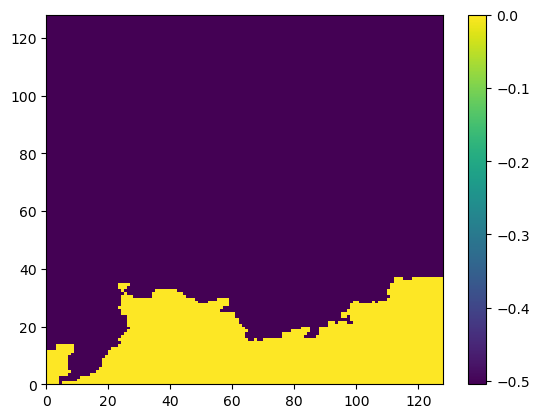

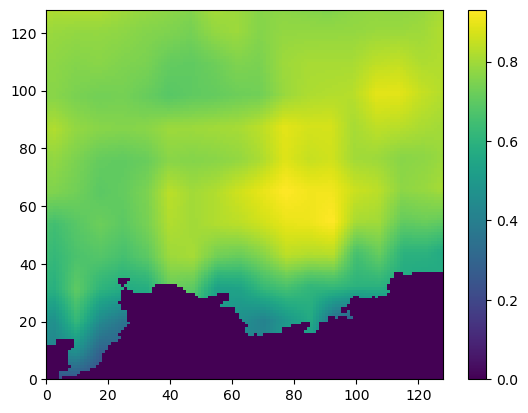

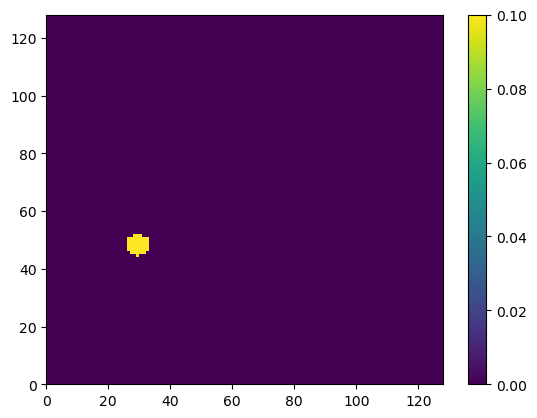

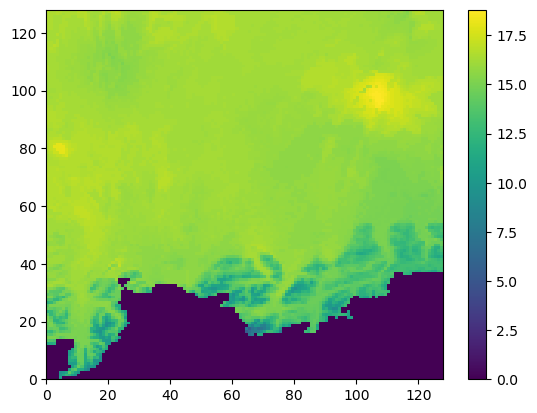

In [22]:
import matplotlib.pyplot as plt
data = dataloader[200]
plt.figure()
plt.pcolormesh(data[1][0])
plt.colorbar()
plt.figure()
plt.pcolormesh(data[1][1])
plt.colorbar()

plt.figure()
plt.pcolormesh(data[0][0])
plt.colorbar()
plt.figure()
plt.pcolormesh(data[0][1])
plt.colorbar()


In [7]:
data

(array([], shape=(2, 128, 0), dtype=float64),
 array([], shape=(7, 128, 0), dtype=float64))

In [27]:
# Test the new patch indexing functionality
# First reload the module to get the updated class
importlib.reload(mod)

# Create dataloader with patch index instead of center_latlon
dataloader_patch = mod.mswxdwd(
    data_path='/beegfs/muduchuru/data',
    input_channels = ['pr','tas'],
    output_channels = ['pr','tas'],
    static_channels = ['elevation', 'lsm', 'dwd_mask','pos_embed'],
    stats_dwd = '/beegfs/muduchuru/data/hyras_daily/hyras_stats.json',
    stats_mswx = '/beegfs/muduchuru/data/mswx/mswx_stats.json',
    patch_index = 5,  # Use patch index 5 instead of center_latlon
    patch_size = (128, 128),
    overlap_pix = 0  # No overlap for systematic patching
)

print(f"Total patches available: {dataloader_patch.get_total_patches(128, 128)}")
print(f"Patch 5 center coordinates: {dataloader_patch.get_patch_center_latlon(5, 128, 128)}")

# Test the data
data_patch = dataloader_patch[200]
print(f"Data shapes: {data_patch[0].shape}, {data_patch[1].shape}")
print("✅ Non-overlapping patch indexing works!")

/home/muduchuru/miniforge3/envs/diffusion/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


Total patches available: 42
Patch 5 center coordinates: (47.78251647949219, 13.849518775939941)
Data shapes: (2, 128, 128), (7, 128, 128)
✅ Non-overlapping patch indexing works!


In [28]:
# Demo: Create a function to generate all patches systematically
def get_all_patches_for_domain(dataloader_class, sample_index, **dataset_kwargs):
    """
    Generate all non-overlapping patches for a given domain systematically.
    
    Parameters
    ----------
    dataloader_class : class
        The dataset class (e.g., mod.mswxdwd)
    sample_index : int
        Index of the time sample to process
    **dataset_kwargs : dict
        Other dataset parameters (data_path, channels, etc.)
        
    Returns
    -------
    list
        List of (patch_data, patch_center_coords, patch_bounds) tuples
    """
    # First create a dataloader to get total patches
    temp_loader = dataloader_class(patch_index=0, **dataset_kwargs)
    total_patches = temp_loader.get_total_patches(128, 128)
    
    patches = []
    for patch_idx in range(total_patches):
        # Create dataloader for this specific patch
        patch_loader = dataloader_class(patch_index=patch_idx, **dataset_kwargs)
        
        # Get the data for this patch
        patch_data = patch_loader[sample_index]
        
        # Get patch metadata
        center_coords = patch_loader.get_patch_center_latlon(patch_idx, 128, 128)
        bounds = patch_loader.get_patch_bounds_by_index(patch_idx, 128, 128)
        
        patches.append({
            'data': patch_data,
            'center_coords': center_coords,
            'bounds': bounds,
            'patch_index': patch_idx
        })
        
    return patches

# Test with first 3 patches
dataset_kwargs = {
    'data_path': '/beegfs/muduchuru/data',
    'input_channels': ['pr','tas'],
    'output_channels': ['pr','tas'], 
    'static_channels': ['elevation', 'lsm', 'dwd_mask','pos_embed'],
    'stats_dwd': '/beegfs/muduchuru/data/hyras_daily/hyras_stats.json',
    'stats_mswx': '/beegfs/muduchuru/data/mswx/mswx_stats.json',
    'patch_size': (128, 128),
    'overlap_pix': 0
}

# Test first 3 patches
first_3_patches = []
for i in range(3):
    patch_loader = mod.mswxdwd(patch_index=i, **dataset_kwargs)
    patch_data = patch_loader[200]
    center = patch_loader.get_patch_center_latlon(i, 128, 128)
    bounds = patch_loader.get_patch_bounds_by_index(i, 128, 128)
    
    first_3_patches.append({
        'patch_index': i,
        'center_coords': center,
        'bounds': bounds,
        'data_shapes': (patch_data[0].shape, patch_data[1].shape)
    })

print("First 3 patches:")
for patch in first_3_patches:
    print(f"Patch {patch['patch_index']}: center={patch['center_coords']}, bounds={patch['bounds']}, shapes={patch['data_shapes']}")
    
print(f"\n✅ Successfully created systematic patch grid with {dataloader_patch.get_total_patches(128, 128)} total patches!")

/home/muduchuru/miniforge3/envs/diffusion/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/muduchuru/miniforge3/envs/diffusion/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/muduchuru/miniforge3/envs/diffusion/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


First 3 patches:
Patch 0: center=(47.80880355834961, 6.99016809463501), bounds=(0, 128, 0, 128), shapes=((2, 128, 128), (7, 128, 128))
Patch 1: center=(47.84238052368164, 8.698113441467285), bounds=(0, 128, 128, 256), shapes=((2, 128, 128), (7, 128, 128))
Patch 2: center=(47.84934997558594, 10.4072904586792), bounds=(0, 128, 256, 384), shapes=((2, 128, 128), (7, 128, 128))

✅ Successfully created systematic patch grid with 42 total patches!


In [29]:
# Demo compatibility with physicsnemo GridPatching2D
from physicsnemo.utils.patching import GridPatching2D
import torch

# Create a full domain sample to demonstrate GridPatching2D compatibility
full_domain_loader = mod.mswxdwd(
    data_path='/beegfs/muduchuru/data',
    input_channels = ['pr','tas'],
    output_channels = ['pr','tas'],
    static_channels = ['elevation', 'lsm', 'dwd_mask','pos_embed'],
    stats_dwd = '/beegfs/muduchuru/data/hyras_daily/hyras_stats.json',
    stats_mswx = '/beegfs/muduchuru/data/mswx/mswx_stats.json',
    patch_size = None,  # No patching - return full domain
)

full_data = full_domain_loader[200]  # Get full domain data
print(f"Full domain shape: {full_data[0].shape}")

# Create GridPatching2D instance
img_shape = full_data[0].shape[-2:]  # (H, W)
patch_shape = (128, 128)
overlap_pix = 0

grid_patcher = GridPatching2D(
    img_shape=img_shape,
    patch_shape=patch_shape, 
    overlap_pix=overlap_pix,
    boundary_pix=0
)

print(f"GridPatching2D will create {grid_patcher.patch_num} patches")
print(f"Our custom method calculates {full_domain_loader.get_total_patches(128, 128)} patches")
print(f"Patch counts match: {grid_patcher.patch_num == full_domain_loader.get_total_patches(128, 128)}")

# Apply GridPatching2D to the data
input_tensor = torch.from_numpy(full_data[1]).unsqueeze(0)  # Add batch dimension (1, C, H, W)
patches = grid_patcher.apply(input_tensor)
print(f"GridPatching2D output shape: {patches.shape}")

# Verify our patch indexing matches GridPatching2D ordering
print("\\nComparing patch centers (first 5 patches):")
for i in range(min(5, grid_patcher.patch_num)):
    our_center = full_domain_loader.get_patch_center_latlon(i, 128, 128)
    our_bounds = full_domain_loader.get_patch_bounds_by_index(i, 128, 128)
    print(f"Patch {i}: center={our_center}, bounds={our_bounds}")

/home/muduchuru/miniforge3/envs/diffusion/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


Full domain shape: (2, 867, 642)
GridPatching2D will create 42 patches
Our custom method calculates 42 patches
Patch counts match: True
GridPatching2D output shape: torch.Size([42, 7, 128, 128])
\nComparing patch centers (first 5 patches):
Patch 0: center=(47.80880355834961, 6.99016809463501), bounds=(0, 128, 0, 128)
Patch 1: center=(47.84238052368164, 8.698113441467285), bounds=(0, 128, 128, 256)
Patch 2: center=(47.84934997558594, 10.4072904586792), bounds=(0, 128, 256, 384)
Patch 3: center=(47.82969665527344, 12.116082191467285), bounds=(0, 128, 384, 512)
Patch 4: center=(47.783451080322266, 13.822874069213867), bounds=(0, 128, 512, 640)


# ✅ Summary: Non-overlapping Patch Indexing

The `mswxdwd` dataset class now supports **systematic non-overlapping patch generation** using patch indices instead of center coordinates. This is perfect for:

## Key Features Added:

1. **`patch_index` parameter**: Specify which patch to extract (0-based indexing)
2. **`overlap_pix` parameter**: Control overlap between patches (default: 0 for non-overlapping)  
3. **Grid-based patch calculation**: Compatible with physicsnemo GridPatching2D
4. **Systematic domain coverage**: Process entire domain without missing areas

## New Methods:

- `get_patch_bounds_by_index(patch_index, ph, pw, overlap_pix)` - Get patch boundaries
- `get_total_patches(ph, pw, overlap_pix)` - Calculate total number of patches  
- `get_patch_center_latlon(patch_index, ph, pw, overlap_pix)` - Get patch center coordinates

## Usage Examples:

```python
# Method 1: Use patch index instead of center_latlon
dataloader = mswxdwd(
    data_path='/path/to/data',
    patch_index=5,  # Extract patch #5
    patch_size=(128, 128),
    overlap_pix=0,  # Non-overlapping
    # ... other parameters
)

# Method 2: Iterate through all patches systematically  
total_patches = dataloader.get_total_patches(128, 128)
for patch_idx in range(total_patches):
    patch_loader = mswxdwd(patch_index=patch_idx, ...)
    data = patch_loader[sample_index]
    # Process patch...
    
# Method 3: Get patch metadata
center_coords = dataloader.get_patch_center_latlon(patch_idx, 128, 128)
bounds = dataloader.get_patch_bounds_by_index(patch_idx, 128, 128)
```

This approach ensures **complete, systematic domain coverage** without overlap or gaps, making it ideal for machine learning workflows that need to process entire geographic domains efficiently.

In [15]:
import importlib.util, sys, os

datasets_dir = "/beegfs/muduchuru/codes/physicsnemo/examples/weather/corrdiff/datasets"

# Create a package module object for 'datasets'
spec_pkg = importlib.util.spec_from_loader("datasets", loader=None)
pkg = importlib.util.module_from_spec(spec_pkg)
pkg.__path__ = [datasets_dir]
sys.modules["datasets"] = pkg

# Now load the submodule as 'datasets.mswx_dwd'
spec = importlib.util.spec_from_file_location("datasets.era5_mswx",
                                              os.path.join(datasets_dir, "era5_mswx.py"))
mod = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = mod
spec.loader.exec_module(mod)

print(mod.era5_mswx)  # class is available

<class 'datasets.era5_mswx.era5_mswx'>


In [18]:
dataloader = mod.era5_mswx(
    data_path='/beegfs/muduchuru/data',
    input_channels = ['pr','tas'],
    output_channels = ['pr','tas'],
    static_channels = ['elevation', 'lsm'],
    stats_era5 = '/beegfs/muduchuru/data/era5/europe_stats.json',
    stats_mswx = '/beegfs/muduchuru/data/mswx/mswx_stats.json',
    )
data = dataloader[200]

In [22]:
dataloader.input_channels()

[ChannelMetadata(name='pr', level='', auxiliary=False),
 ChannelMetadata(name='tas', level='', auxiliary=False),
 ChannelMetadata(name='elevation', level='', auxiliary=False),
 ChannelMetadata(name='lsm', level='', auxiliary=False)]

In [6]:
import xarray as xr
ds = xr.open_dataset('/data01/FDS/muduchuru/Atmos/ERA5/cmip_var/era5/daily_nc/europe/combined/ERA5_2023-03-11_26var.nc')


In [7]:
ds

<xarray.Dataset> Size: 6MB
Dimensions:  (time: 1, channel: 26, lon: 237, lat: 229)
Coordinates:
  * time     (time) datetime64[ns] 8B 2023-03-11
  * channel  (channel) <U6 624B '2d' 'hus200' 'hus500' ... 'zg700' 'zg850'
  * lon      (lon) float64 2kB -14.0 -13.75 -13.5 -13.25 ... 44.5 44.75 45.0
  * lat      (lat) float64 2kB 75.0 74.75 74.5 74.25 ... 18.75 18.5 18.25 18.0
Data variables:
    image    (time, channel, lat, lon) float32 6MB ...
Attributes:
    variables:    2d,hus200,hus500,hus700,hus850,pr,rsds,ta200,ta500,ta700,ta...
    source:       ERA5 reanalysis
    institution:  European Centre for Medium-Range Weather Forecasts
    Conventions:  CF-1.6
    date:         2023-03-11